## Phase 5 — Data Visualization

With a fully cleaned and analyzed dataset, we now translate our 
findings into visual form. Good visualizations don't just show 
numbers — they make patterns immediately obvious that tables and 
text cannot.

Every chart in this phase directly visualizes a finding from 
Phase 3. No chart exists without a purpose.

Charts covered:
1. Genre distribution in the Netflix library
2. Average ROI by genre
3. Revenue by budget tier
4. Flop rate by budget tier
5. Budget vs revenue relationship
6. Movie quality trend over the years
7. Top non-English languages by revenue
8. Correlation heatmap
9. Rating distribution across the library
10. Popularity spike in recent years

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Consistent style across all charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Load cleaned data
df = pd.read_csv('data/netflix_cleaned.csv')

# Recreate financial subset
financial_df = df[df['budget'].notna() & df['revenue'].notna()].copy()
financial_df['profit'] = financial_df['revenue'] - financial_df['budget']
financial_df['roi_pct'] = ((financial_df['revenue'] - financial_df['budget']) / financial_df['budget']) * 100
financial_df['was_flop'] = financial_df['revenue'] < financial_df['budget']
financial_df['budget_tier'] = pd.cut(
    financial_df['budget'],
    bins=[0, 10_000_000, 50_000_000, 100_000_000, float('inf')],
    labels=['Low (<$10M)', 'Mid ($10-50M)', 'High ($50-100M)', 'Blockbuster ($100M+)']
)

# Recreate genre exploded dataframe
df_genres = df.assign(
    genre=df['genres'].str.split(', ')
).explode('genre')

# Recreate financial genres for ROI by genre analysis
financial_genres = financial_df.assign(
    genre=financial_df['genres'].str.split(', ')
).explode('genre')

print(f"Main df: {df.shape}")
print(f"Financial df: {financial_df.shape}")
print(f"Genre df: {df_genres.shape}")
print("All dataframes ready")
os.makedirs('charts', exist_ok=True)
print("Charts folder ready")

Main df: (15893, 18)
Financial df: (3540, 22)
Genre df: (37460, 19)
All dataframes ready
Charts folder ready


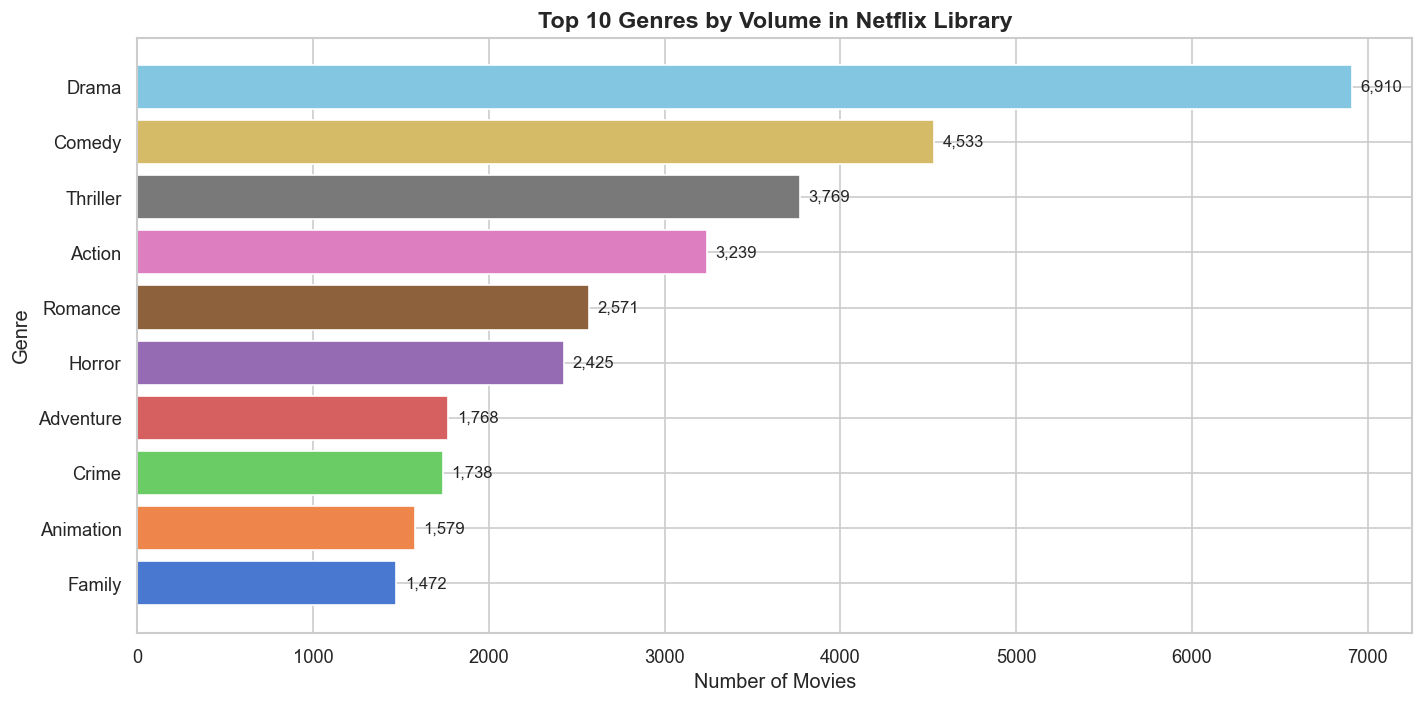

In [3]:
# Top 10 genres by volume in the library
genre_counts = df_genres['genre'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], 
               color=sns.color_palette('muted', 10))
ax.set_title('Top 10 Genres by Volume in Netflix Library')
ax.set_xlabel('Number of Movies')
ax.set_ylabel('Genre')

# Add value labels on bars
for bar, val in zip(bars, genre_counts.values[::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('charts/chart1_genre_distribution.png', bbox_inches='tight')
plt.show()

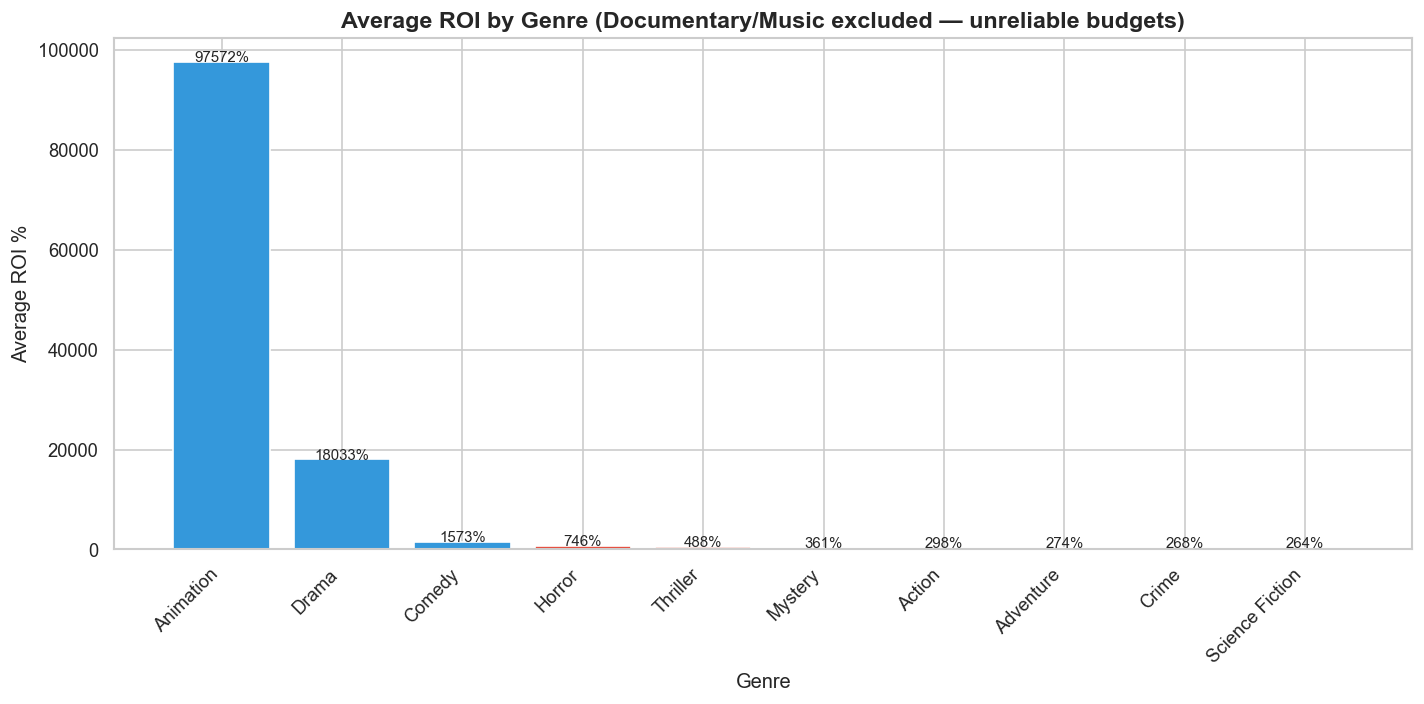

In [4]:
# Average ROI by genre — exclude Documentary and Music outliers
roi_by_genre = (
    financial_genres.groupby('genre')['roi_pct']
    .mean()
    .sort_values(ascending=False)
    .drop(['Documentary', 'Music', 'History'])  # extreme outliers
    .head(10)
    .round(1)
)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if x in ['Horror', 'Thriller'] 
          else '#3498db' for x in roi_by_genre.index]
bars = ax.bar(roi_by_genre.index, roi_by_genre.values, color=colors)
ax.set_title('Average ROI by Genre (Documentary/Music excluded — unreliable budgets)')
ax.set_xlabel('Genre')
ax.set_ylabel('Average ROI %')
plt.xticks(rotation=45, ha='right')

# Highlight Horror and Thriller
for bar, val in zip(bars, roi_by_genre.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('charts/chart2_roi_by_genre.png', bbox_inches='tight')
plt.show()

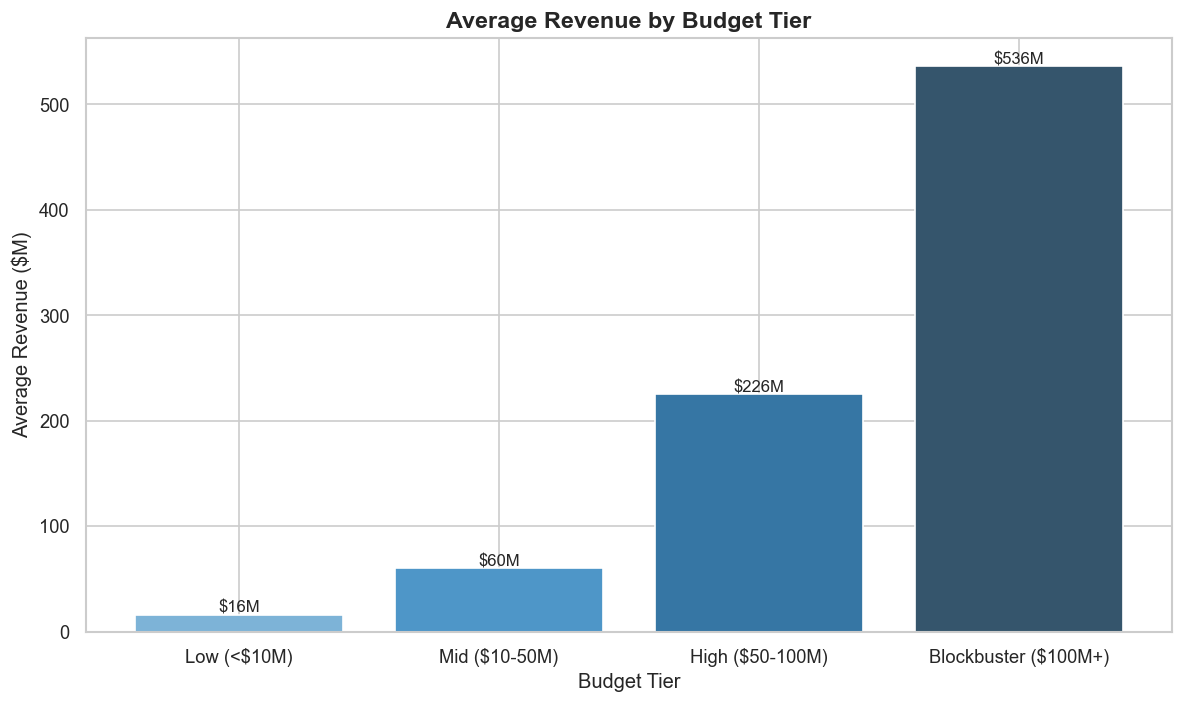

In [5]:
revenue_by_tier = financial_df.groupby('budget_tier', observed=True)['revenue'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(revenue_by_tier.index, revenue_by_tier.values / 1_000_000,
              color=sns.color_palette('Blues_d', 4))
ax.set_title('Average Revenue by Budget Tier')
ax.set_xlabel('Budget Tier')
ax.set_ylabel('Average Revenue ($M)')

for bar, val in zip(bars, revenue_by_tier.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'${val/1_000_000:.0f}M', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('charts/chart3_revenue_by_budget_tier.png', bbox_inches='tight')
plt.show()

### Chart 2 Requires Correction

Visual inspection revealed Animation (97,572% avg ROI) and Drama 
(18,033% avg ROI) are extreme outliers. Investigation shows these 
are caused by movies with clearly erroneous budgets — as low as $5, 
$84, and $105 — which are data entry errors, not real production costs.

No movie is produced for under $1,000. These rows survived initial 
cleaning because budget > 0, but they represent corrupt data not 
caught in Phase 1.

Fix: Apply a minimum budget threshold of $10,000 before ROI 
analysis. This removes statistically impossible entries while 
preserving legitimate low-budget independent films.

In [6]:
# Fix — remove impossibly low budgets before ROI chart
financial_genres_clean = financial_genres[financial_genres['budget'] >= 10_000]

print(f"Rows removed: {len(financial_genres) - len(financial_genres_clean)}")
print(f"Rows remaining: {len(financial_genres_clean)}")

# Check Animation and Drama now
print("\nAnimation median ROI after fix:", 
      round(financial_genres_clean[financial_genres_clean['genre']=='Animation']['roi_pct'].median(), 1))
print("Drama median ROI after fix:", 
      round(financial_genres_clean[financial_genres_clean['genre']=='Drama']['roi_pct'].median(), 1))

Rows removed: 32
Rows remaining: 9152

Animation median ROI after fix: 126.7
Drama median ROI after fix: 27.6


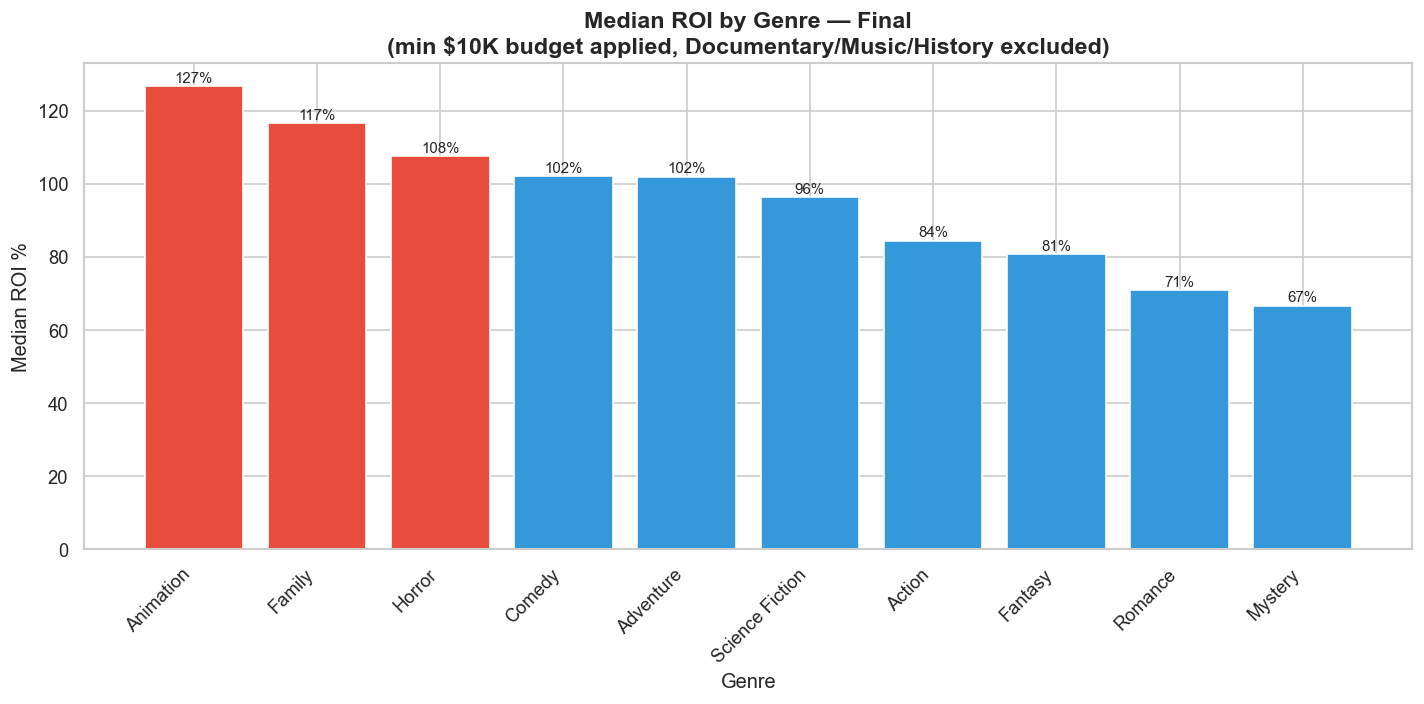

In [7]:
# Chart 2 Final — correct highlights based on cleaned data
roi_by_genre_final = (
    financial_genres_clean
    .groupby('genre')['roi_pct']
    .median()
    .sort_values(ascending=False)
    .drop(['Documentary', 'Music', 'History'], errors='ignore')
    .head(10)
    .round(1)
)

fig, ax = plt.subplots(figsize=(12, 6))

# Green for top performers, red for Horror specifically, blue for rest
highlight = ['Animation', 'Family', 'Horror']
colors = ['#e74c3c' if x in highlight else '#3498db' 
          for x in roi_by_genre_final.index]

bars = ax.bar(roi_by_genre_final.index, roi_by_genre_final.values, color=colors)
ax.set_title('Median ROI by Genre — Final\n(min $10K budget applied, Documentary/Music/History excluded)')
ax.set_xlabel('Genre')
ax.set_ylabel('Median ROI %')
plt.xticks(rotation=45, ha='right')

for bar, val in zip(bars, roi_by_genre_final.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('charts/chart2_roi_by_genre_final.png', bbox_inches='tight')
plt.show()

### Finding — Thriller ROI Was Outlier Driven

After applying the $10K minimum budget threshold, Thriller drops 
to 13th place at 35.6% median ROI — significantly below its 
pre-correction mean of 488%. This confirms Thriller's earlier 
strong appearance was entirely caused by a small number of movies 
with near-zero recorded budgets inflating the average.

The corrected top performers are Animation (127%), Family (117%), 
and Horror (108%). These three genres consistently return more 
than double their investment at median — meaning even the typical 
film in these genres, not just the best ones, performs well.

This finding updates our investment recommendation — Horror remains 
valid but Thriller is removed as a primary recommendation. 
Animation and Family emerge as stronger alternatives than 
initially identified.

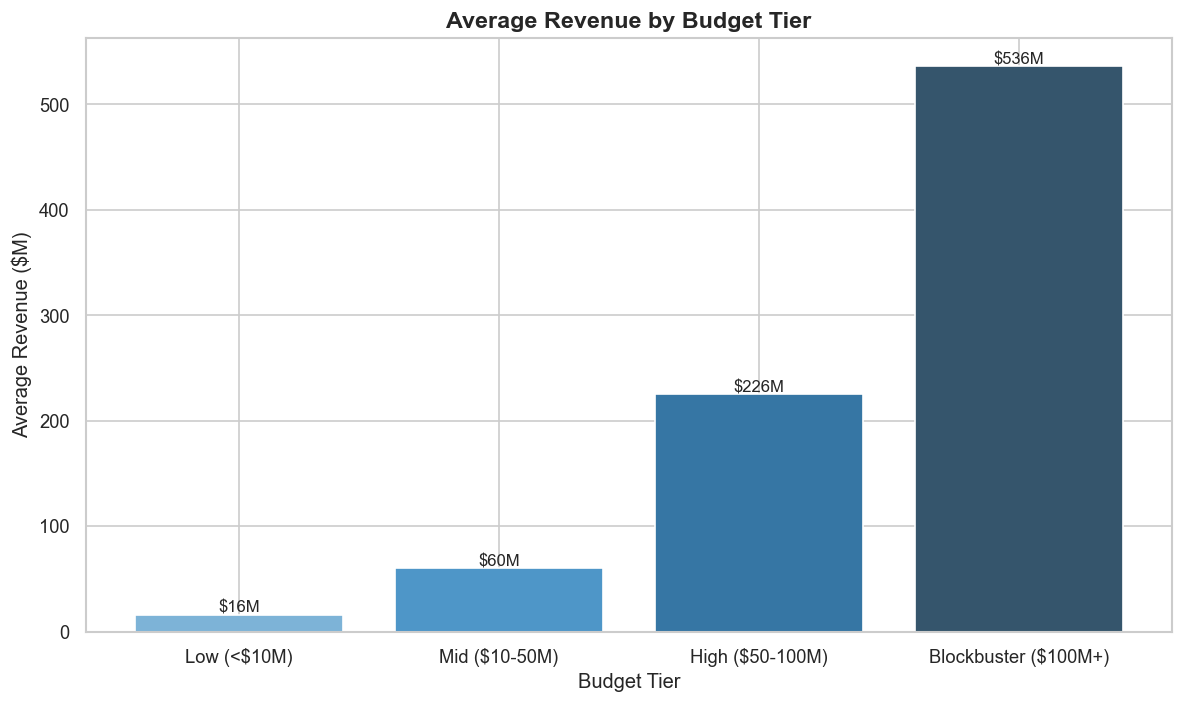

In [8]:
revenue_by_tier = financial_df.groupby('budget_tier', observed=True)['revenue'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(revenue_by_tier.index, revenue_by_tier.values / 1_000_000,
              color=sns.color_palette('Blues_d', 4))
ax.set_title('Average Revenue by Budget Tier')
ax.set_xlabel('Budget Tier')
ax.set_ylabel('Average Revenue ($M)')

for bar, val in zip(bars, revenue_by_tier.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'${val/1_000_000:.0f}M', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('charts/chart3_revenue_by_budget_tier.png', bbox_inches='tight')
plt.show()

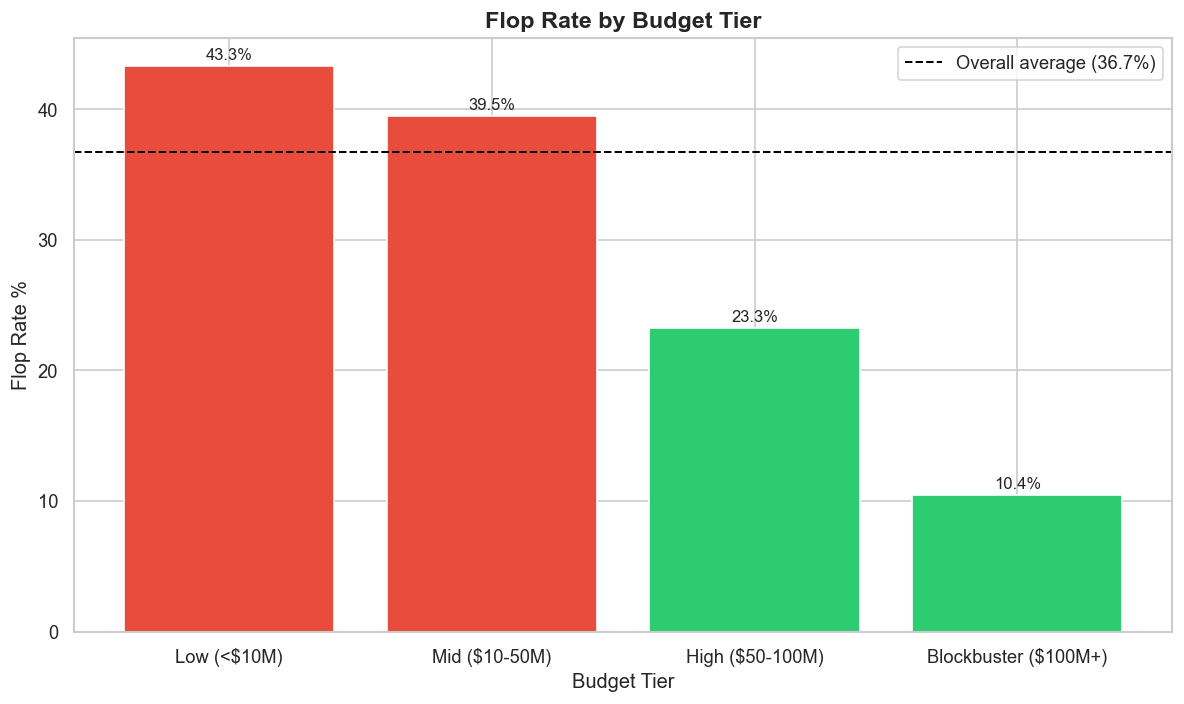

In [9]:
flop_by_tier = financial_df.groupby('budget_tier', 
               observed=True)['was_flop'].mean().mul(100)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v > 35 else '#2ecc71' for v in flop_by_tier.values]
bars = ax.bar(flop_by_tier.index, flop_by_tier.values, color=colors)
ax.axhline(y=36.7, color='black', linestyle='--', 
           linewidth=1.2, label='Overall average (36.7%)')
ax.set_title('Flop Rate by Budget Tier')
ax.set_xlabel('Budget Tier')
ax.set_ylabel('Flop Rate %')
ax.legend()

for bar, val in zip(bars, flop_by_tier.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('charts/chart4_flop_rate_by_tier.png', bbox_inches='tight')
plt.show()

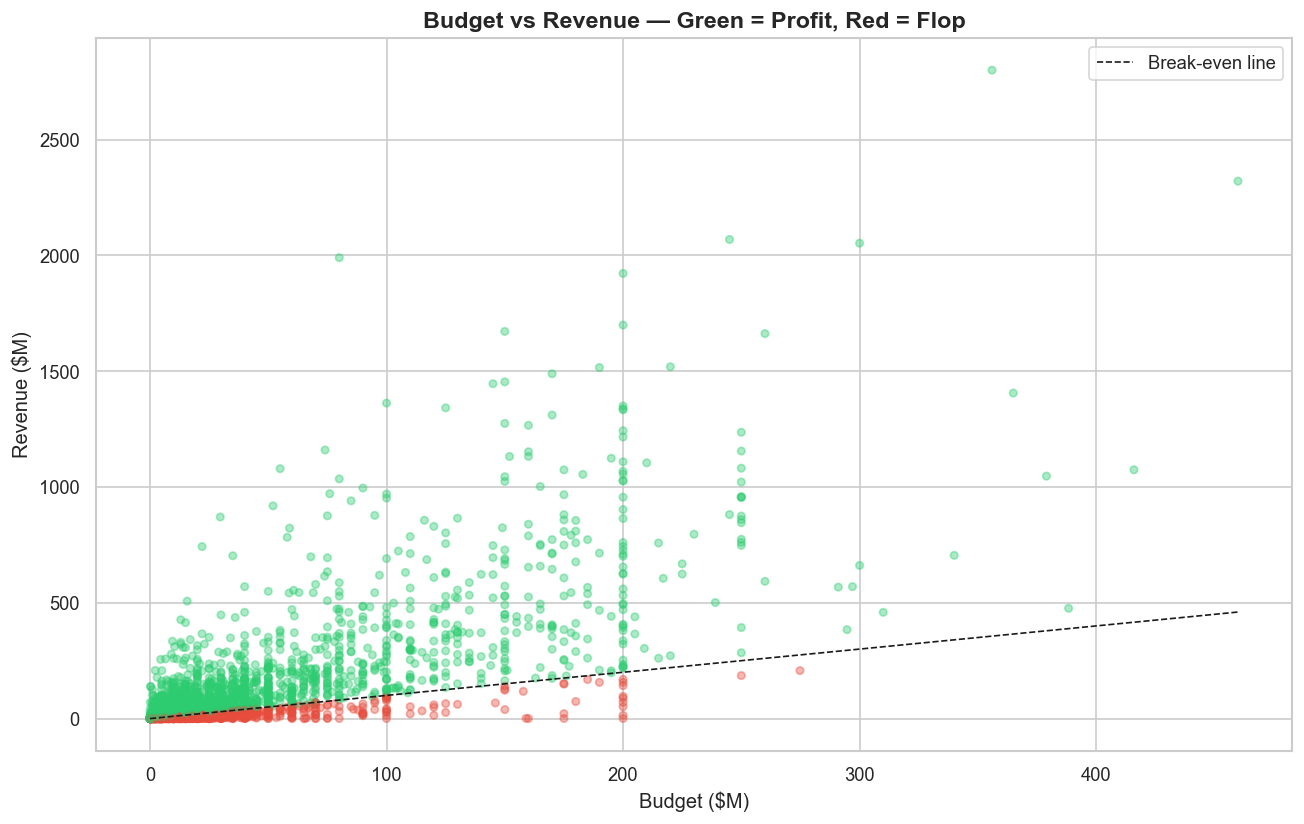

In [10]:
fig, ax = plt.subplots(figsize=(11, 7))

# Plot points colored by flop status
colors = financial_df['was_flop'].map({True: '#e74c3c', False: '#2ecc71'})
ax.scatter(financial_df['budget'] / 1_000_000,
           financial_df['revenue'] / 1_000_000,
           c=colors, alpha=0.4, s=20)

# Add diagonal break-even line
max_val = financial_df['budget'].max() / 1_000_000
ax.plot([0, max_val], [0, max_val], 'k--', 
        linewidth=1, label='Break-even line')

ax.set_title('Budget vs Revenue — Green = Profit, Red = Flop')
ax.set_xlabel('Budget ($M)')
ax.set_ylabel('Revenue ($M)')
ax.legend()

plt.tight_layout()
plt.savefig('charts/chart5_budget_vs_revenue.png', bbox_inches='tight')
plt.show()

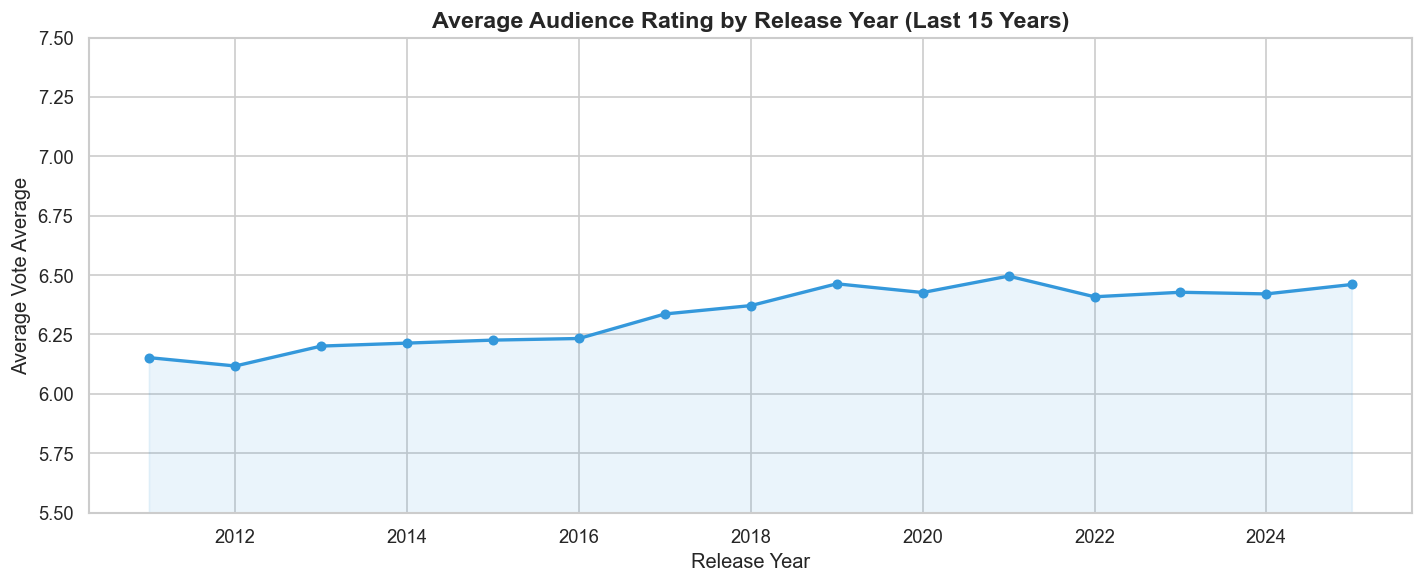

In [11]:
rated = df[df['vote_average'] > 0]
quality_trend = rated.groupby('release_year')['vote_average'].mean().tail(15)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(quality_trend.index, quality_trend.values, 
        marker='o', linewidth=2, color='#3498db', markersize=5)
ax.fill_between(quality_trend.index, quality_trend.values, 
                alpha=0.1, color='#3498db')
ax.set_title('Average Audience Rating by Release Year (Last 15 Years)')
ax.set_xlabel('Release Year')
ax.set_ylabel('Average Vote Average')
ax.set_ylim(5.5, 7.5)

plt.tight_layout()
plt.savefig('charts/chart6_quality_trend.png', bbox_inches='tight')
plt.show()

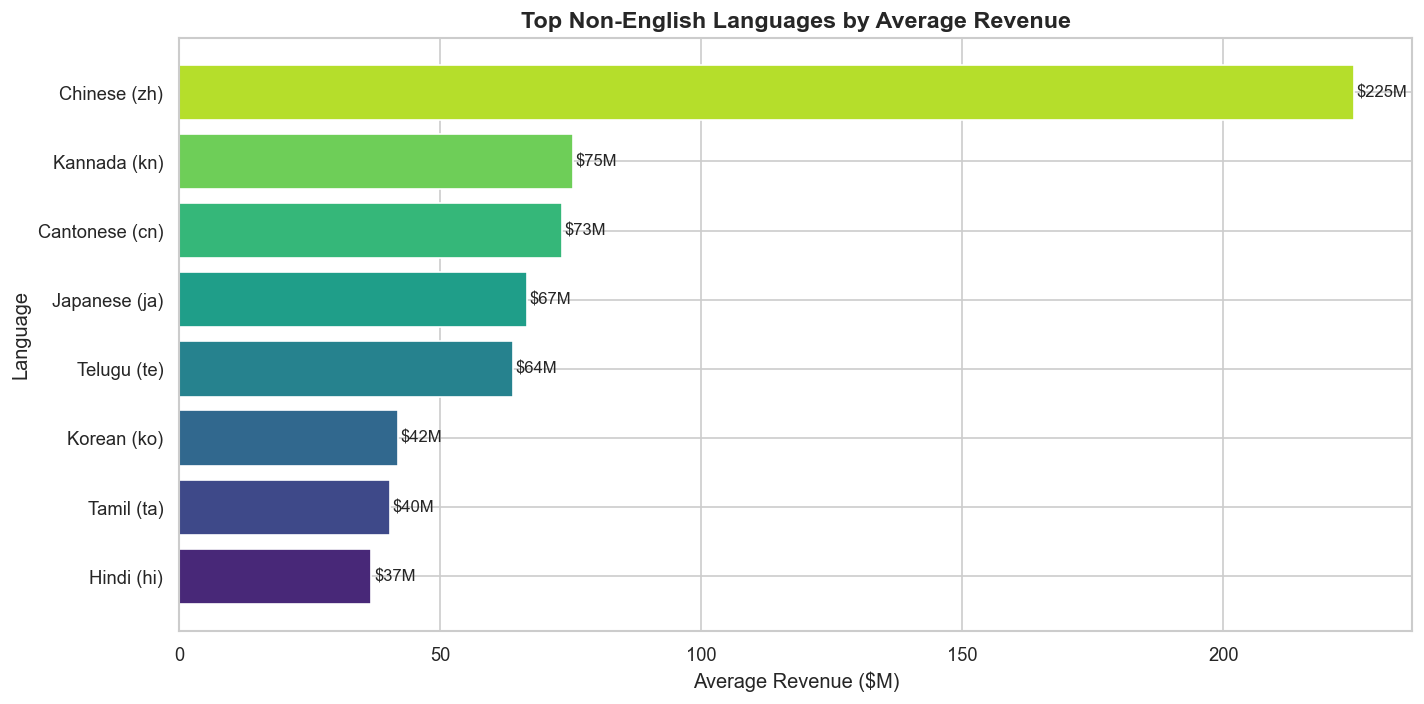

In [12]:
# Chart 7 Fixed — add readable language names
lang_names = {
    'zh': 'Chinese (zh)',
    'kn': 'Kannada (kn)', 
    'cn': 'Cantonese (cn)',
    'ja': 'Japanese (ja)',
    'te': 'Telugu (te)',
    'ko': 'Korean (ko)',
    'ta': 'Tamil (ta)',
    'hi': 'Hindi (hi)'
}

non_english = financial_df[financial_df['language'] != 'en']
lang_revenue = (non_english.groupby('language')['revenue']
                .mean()
                .sort_values(ascending=False)
                .head(8))

# Map to readable names
lang_revenue.index = [lang_names.get(x, x) for x in lang_revenue.index]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(lang_revenue.index[::-1],
               lang_revenue.values[::-1] / 1_000_000,
               color=sns.color_palette('viridis', 8))
ax.set_title('Top Non-English Languages by Average Revenue')
ax.set_xlabel('Average Revenue ($M)')
ax.set_ylabel('Language')

for bar, val in zip(bars, lang_revenue.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'${val/1_000_000:.0f}M', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('charts/chart7_language_revenue_fixed.png', bbox_inches='tight')
plt.show()

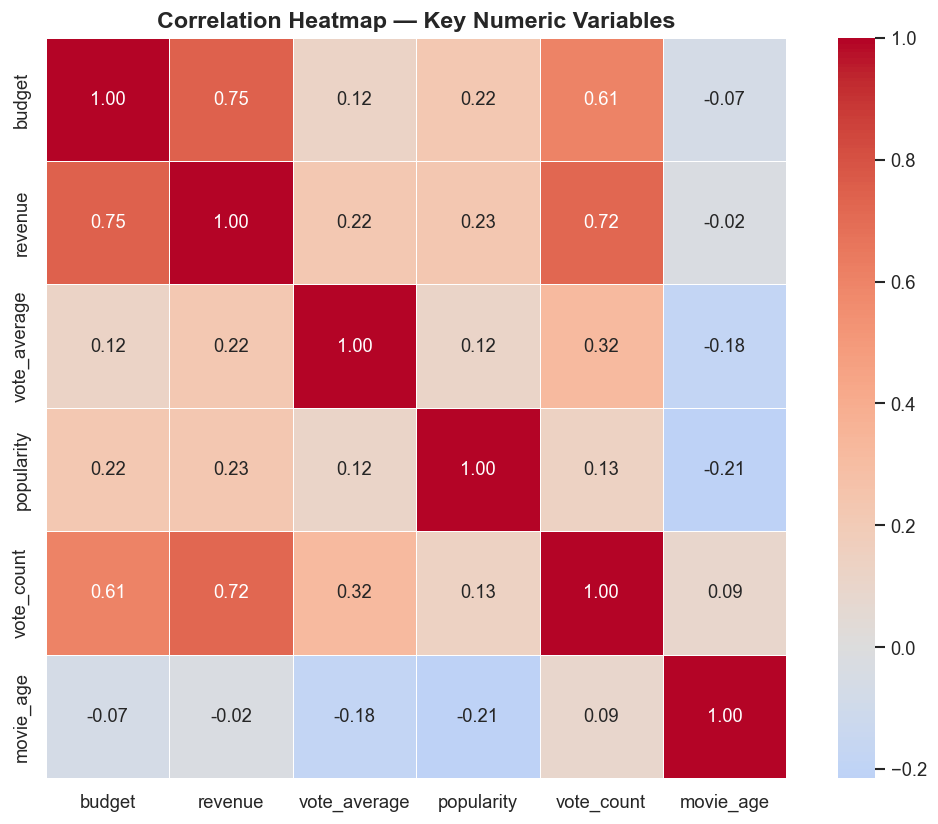

In [13]:
corr_cols = ['budget', 'revenue', 'vote_average', 
             'popularity', 'vote_count', 'movie_age']
corr_matrix = financial_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Key Numeric Variables')

plt.tight_layout()
plt.savefig('charts/chart8_correlation_heatmap.png', bbox_inches='tight')
plt.show()

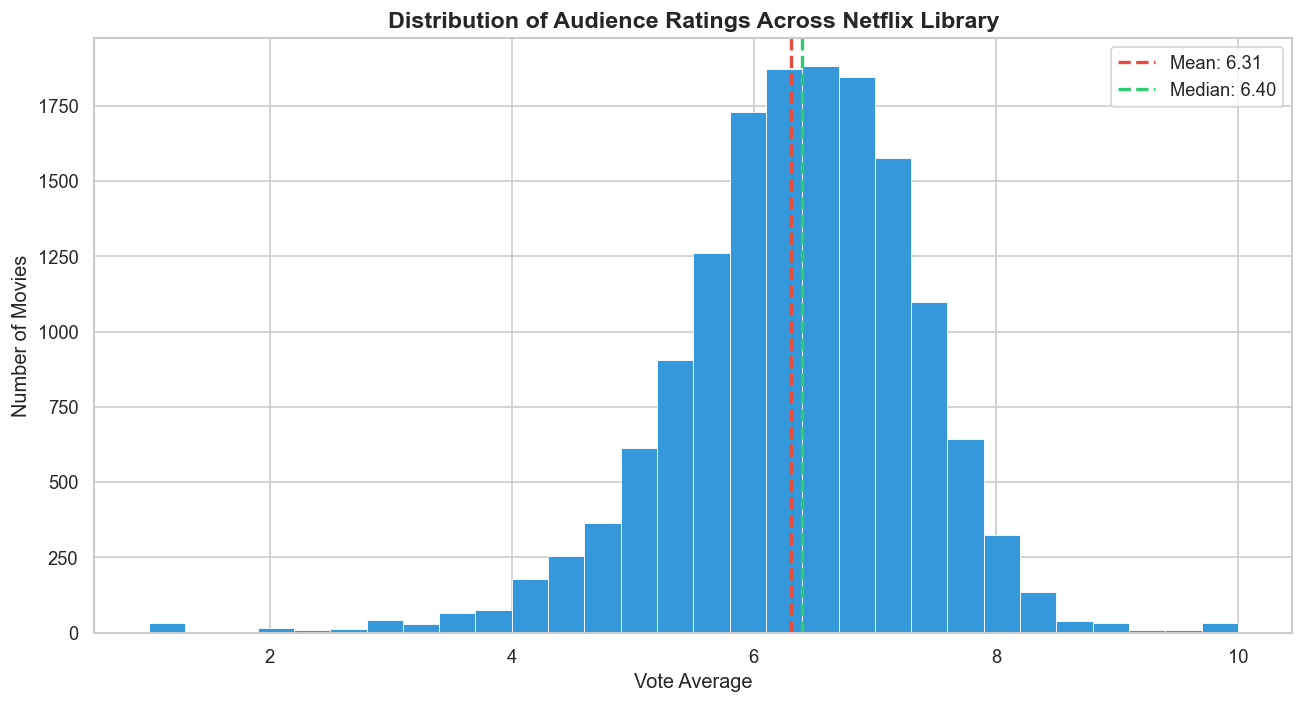

In [14]:
rated = df[df['vote_average'] > 0]

fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(rated['vote_average'], bins=30, 
        color='#3498db', edgecolor='white', linewidth=0.5)
ax.axvline(rated['vote_average'].mean(), color='#e74c3c', 
           linestyle='--', linewidth=2,
           label=f"Mean: {rated['vote_average'].mean():.2f}")
ax.axvline(rated['vote_average'].median(), color='#2ecc71',
           linestyle='--', linewidth=2,
           label=f"Median: {rated['vote_average'].median():.2f}")
ax.set_title('Distribution of Audience Ratings Across Netflix Library')
ax.set_xlabel('Vote Average')
ax.set_ylabel('Number of Movies')
ax.legend()

plt.tight_layout()
plt.savefig('charts/chart9_rating_distribution.png', bbox_inches='tight')
plt.show()

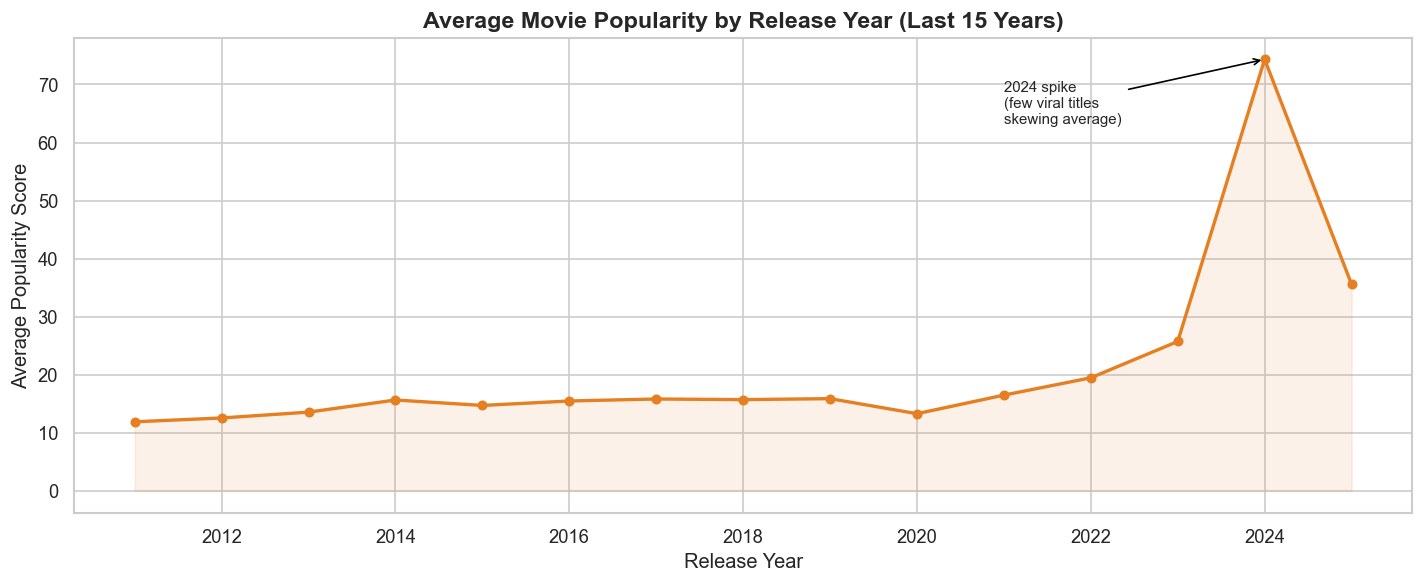

In [15]:
pop_trend = df.groupby('release_year')['popularity'].mean().tail(15)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pop_trend.index, pop_trend.values,
        marker='o', linewidth=2, color='#e67e22', markersize=5)
ax.fill_between(pop_trend.index, pop_trend.values,
                alpha=0.1, color='#e67e22')
ax.set_title('Average Movie Popularity by Release Year (Last 15 Years)')
ax.set_xlabel('Release Year')
ax.set_ylabel('Average Popularity Score')

# Annotate the 2024 spike
ax.annotate('2024 spike\n(few viral titles\nskewing average)',
            xy=(2024, pop_trend[2024]),
            xytext=(2021, pop_trend[2024] * 0.85),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9)

plt.tight_layout()
plt.savefig('charts/chart10_popularity_trend.png', bbox_inches='tight')
plt.show()